## 1. Imports and Setup

This section imports all the necessary libraries for data preprocessing, model building, evaluation, and ensemble learning. Ensemble methods like RandomForest, GradientBoosting, Voting, and Stacking are included because they often improve performance by combining predictions from multiple classifiers.

In [168]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')
import joblib

from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score, learning_curve, validation_curve, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer, StandardScaler, PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score, average_precision_score, precision_recall_curve, roc_curve, f1_score, precision_score, recall_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, VotingClassifier, StackingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)


## 2. Data Loading and Cleaning

Here we load the Adult Income dataset and clean it. Missing values indicated by '?' are replaced with 'Unknown'. String columns are stripped of spaces, and columns `fnlwgt` and `education` are dropped because they are not useful for prediction.

In [153]:
# df_train = pd.read_csv("data/adult_train_cleaned.csv")
# df_test = pd.read_csv("data/adult.test")
# df_train.head(2)

# df_train = pd.read_csv("data/adult_train_cleaned.csv")
# df_test = pd.read_csv("data/adult.test")
# def load_and_basic_clean(train_path="data/adult.data", test_path="data/adult.test"):
#     column_names = [
#         "age","workclass","fnlwgt","education","education-num","marital-status",
#         "occupation","relationship","race","sex","capital-gain","capital-loss",
#         "hours-per-week","native-country","income"
#     ]
#     df_train = pd.read_csv(train_path, names=column_names)
#     df_test  = pd.read_csv(test_path, skiprows=1, names=column_names)
# 
#     for col in ["workclass", "occupation", "native-country"]:
#         df_train[col] = df_train[col].replace("?", "Unknown")
#         df_test[col]  = df_test[col].replace("?", "Unknown")
# 
#     for df in (df_train, df_test):
#         obj_cols = df.select_dtypes(include="object").columns
#         for c in obj_cols:
#             df[c] = df[c].str.strip()
# 
#     df_train["income"] = df_train["income"].str.replace(".", "", regex=False)
#     df_test["income"]  = df_test["income"].str.replace(".", "", regex=False)
# 
#     df_train = df_train.drop(columns=["fnlwgt", "education"]) 
#     df_test  = df_test.drop(columns=["fnlwgt", "education"]) 
# # 
#     return df_train, df_test
# # 
# df_train, df_test = load_and_basic_clean()
# df_train.head(2)


,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K


## 3. Define Target and Features

The target variable is binary: 1 if income >50K, 0 otherwise. We separate the features and target for both training and holdout sets and check the positive class distribution.

In [154]:
# TARGET = "income"
# X = df_train.drop(columns=[TARGET])
# y = (df_train[TARGET] == ">50K").astype(int)
# 
# X_holdout = df_test.drop(columns=[TARGET])
# y_holdout = (df_test[TARGET] == ">50K").astype(int)
# 
# print("Positive rate in train:", y.mean().round(3), " | Positive rate in holdout:", y_holdout.mean().round(3))
# 
# 
# X = df_train.drop('income', axis=1)
# y = df_train['income'].apply(lambda x: 1 if x == '>50K' else 0)
# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
# print("Train size:", X_train.shape, "| Validation size:", X_val.shape)


Positive rate in train: 0.241  | Positive rate in holdout: 0.236


## 4. Preprocessing Pipelines

Numeric features are split into skewed and non-skewed. Skewed numeric columns are log-transformed to reduce skewness. Categorical columns are imputed with the most frequent value and one-hot encoded.

In [155]:
 
# numeric_cols_all = X.select_dtypes(include=[np.number]).columns.tolist()
# skewed_numeric = [c for c in ["capital-gain", "capital-loss"] if c in numeric_cols_all]
# base_numeric   = [c for c in numeric_cols_all if c not in skewed_numeric]
# categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
# 
# numeric_base = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())
# numeric_skewed = make_pipeline(SimpleImputer(strategy="median"), FunctionTransformer(np.log1p, feature_names_out="one-to-one"), StandardScaler())
# categorical = make_pipeline(SimpleImputer(strategy="most_frequent"), OneHotEncoder(handle_unknown="ignore", min_frequency=0.01, sparse_output=False))
# 
# preprocess = ColumnTransformer([
#     ("num_base", numeric_base, base_numeric),
#     ("num_skewed", numeric_skewed, skewed_numeric),
#     ("cat", categorical, categorical_cols),
# ], remainder="drop", verbose_feature_names_out=False)

# preprocess = joblib.load("data/preprocessor.pkl")
# print(preprocess)

In [170]:
# Rufinas code
cols = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
    'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
    'hours-per-week', 'native-country', 'income'
]

df = pd.read_csv('./data/adult.data', header=None, names=cols, na_values='?', skipinitialspace=True)
df_test = pd.read_csv('./data/adult.test', skiprows=1, header=None, names=cols, na_values='?', skipinitialspace=True)

print("Train shape:", df.shape, " | Test shape:", df_test.shape)
print(df.head())
df.drop_duplicates(inplace=True)
df.drop(columns='fnlwgt', inplace=True)
df_test.drop(columns='fnlwgt', inplace=True)

for d in [df, df_test]:
    d = d.apply(lambda x: x.str.strip() if x.dtype == "object" else x)
    d['income'] = d['income'].str.replace('.', '', regex=False)

for col in ['workclass', 'occupation', 'native-country']:
    df[col] = df[col].fillna('Unknown')
    df_test[col] = df_test[col].fillna('Unknown')

print("After cleaning missing values:")
for col in ['workclass', 'occupation', 'native-country']:
    print(f"{col:15}: {df[col].isna().sum()} missing, {(df[col]=='Unknown').sum()} Unknown")
df['is_senior'] = np.where(df['age'] >= 60, 1, 0)
df_test['is_senior'] = np.where(df_test['age'] >= 60, 1, 0)

for col in ['capital-gain', 'capital-loss']:
    df[col + '_log'] = np.log1p(df[col])
    df_test[col + '_log'] = np.log1p(df_test[col])
df['education_per_age'] = df['education-num'] / df['age']
df_test['education_per_age'] = df_test['education-num'] / df_test['age']

df['work_gain_ratio'] = df['hours-per-week'] * (df['capital-gain_log'] + 1)
df_test['work_gain_ratio'] = df_test['hours-per-week'] * (df_test['capital-gain_log'] + 1)

df['is_married'] = df['marital-status'].apply(lambda x: 1 if 'Married' in x else 0)
df_test['is_married'] = df_test['marital-status'].apply(lambda x: 1 if 'Married' in x else 0)

df['gender_role'] = df['sex'] + '_' + df['relationship']
df_test['gender_role'] = df_test['sex'] + '_' + df_test['relationship']

age_bins = [0, 25, 35, 45, 55, 65, 100]
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=['<25', '25–35', '35–45', '45–55', '55–65', '65+'])
df_test['age_group'] = pd.cut(df_test['age'], bins=age_bins, labels=['<25', '25–35', '35–45', '45–55', '55–65', '65+'])
X = df.drop('income', axis=1)
y = df['income'].apply(lambda x: 1 if x == '>50K' else 0)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print("Train size:", X_train.shape, "| Validation size:", X_val.shape)
## 6.1 At this stage we can save cleaned, preprocessed and feature-engineered dataset before model transformations.
processed_train = pd.concat([X_train, y_train], axis=1)
processed_train.to_csv('./data/adult_train_cleaned.csv', index=False)
print(processed_train.head(5))
numeric_features = [
    'age', 'education-num', 'hours-per-week',
    'capital-gain_log', 'capital-loss_log',
    'education_per_age', 'work_gain_ratio'
]

categorical_features = [
    'workclass', 'marital-status', 'occupation', 'relationship',
    'race', 'sex', 'native-country',
    'is_senior', 'is_married', 'gender_role', 'age_group'
]
print("Numeric:", numeric_features)
print("Categorical:", categorical_features)
numeric_transformer = Pipeline([
    ('scaler', StandardScaler()),
    ('power', PowerTransformer(method='yeo-johnson'))
])

categorical_transformer = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])


# joblib.dump(preprocessor, 'data/preprocessor.pkl')

Train shape: (32561, 15)  | Test shape: (16281, 15)
   age         workclass  fnlwgt  education  education-num      marital-status         occupation   relationship   race     sex  \
0   39         State-gov   77516  Bachelors             13       Never-married       Adm-clerical  Not-in-family  White    Male   
1   50  Self-emp-not-inc   83311  Bachelors             13  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2   38           Private  215646    HS-grad              9            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3   53           Private  234721       11th              7  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4   28           Private  338409  Bachelors             13  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital-gain  capital-loss  hours-per-week native-country income  
0          2174             0              40  United-States  <=50K  
1             0      

## 5. Define Base and Ensemble Models

Tree-based and boosting methods usually perform well on tabular data. Voting and stacking ensembles are included to combine strengths of multiple models.

In [171]:

logreg = LogisticRegression(max_iter=1000)
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)
ada = AdaBoostClassifier(random_state=42)
svc = SVC(probability=True, random_state=42)
knn = KNeighborsClassifier()
voting = VotingClassifier(estimators=[('lr', logreg), ('rf', rf), ('gb', gb)], voting='soft')
stacking = StackingClassifier(estimators=[('lr', logreg), ('rf', rf), ('gb', gb), ('svc', svc)], final_estimator=LogisticRegression(max_iter=1000))

models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "SVC": SVC(probability=True, random_state=42),
    "KNeighbors": KNeighborsClassifier(),
    "VotingEnsemble": voting,
    "StackingEnsemble": stacking
}

## 6. Build Pipelines and Hyperparameter Grids

Hyperparameter grids are defined for models that support tuning. Voting and stacking ensembles are not tuned directly.

In [172]:
pipelines = {name: Pipeline([('preprocess', preprocessor), ('clf', model)]) for name, model in models.items()}

param_grids = {
    "LogisticRegression": {
        'clf__C': [0.1, 1.0, 10.0],
        'clf__penalty': ['l2', None],
        'clf__solver': ['lbfgs', 'saga']
    },
    "DecisionTree": {
        'clf__max_depth': [3, 5, 7, 10, None],
        'clf__min_samples_split': [2, 5, 10],
        'clf__min_samples_leaf': [1, 2, 4]
    },
    "RandomForest": {
        'clf__n_estimators': [100, 200],
        'clf__max_depth': [5, 10, None],
        'clf__min_samples_split': [2, 5],
        'clf__max_features': ['sqrt', 'log2']
    },
    "GradientBoosting": {
        'clf__n_estimators': [100, 200],
        'clf__learning_rate': [0.05, 0.1, 0.2],
        'clf__max_depth': [3, 5],
        'clf__subsample': [0.8, 1.0]
    },
    "AdaBoost": {
        'clf__n_estimators': [50, 100, 200],
        'clf__learning_rate': [0.5, 1.0, 1.5]
    },
    "SVC": {
        'clf__C': [0.1, 1.0, 10.0],
        'clf__kernel': ['rbf', 'linear'],
        'clf__gamma': ['scale', 'auto']
    },
    "KNeighbors": {
        'clf__n_neighbors': [3, 5, 7, 10],
        'clf__weights': ['uniform', 'distance'],
        'clf__metric': ['euclidean', 'manhattan']
    },
    "VotingEnsemble": {},
    "StackingEnsemble": {}
}


## 7. Model Training and Hyperparameter Tuning

5-fold stratified cross-validation ensures class balance. Each model is tuned using ROC-AUC.

In [173]:
# this is the one thats failing if separated

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}
best_estimators = {}
training_times = {}

print("\n" + "="*50)
print("MODEL TRAINING AND HYPERPARAMETER TUNING")
print("="*50)

for name, pipeline in pipelines.items():
    print(f"\n--- Training {name} ---")
    start_time = time.time()
    
    if param_grids[name]:
        # Hyperparameter tuning with GridSearchCV
        gs = GridSearchCV(pipeline, param_grids[name], scoring='roc_auc', 
                         cv=cv, n_jobs=-1, verbose=0)
        gs.fit(X, y)
        best_estimators[name] = gs.best_estimator_
        best_score = gs.best_score_
        best_params = gs.best_params_
        
        print(f"Best parameters: {best_params}")
        print(f"Best CV ROC-AUC: {best_score:.4f}")
    else:
        # For ensemble methods without hyperparameter tuning
        pipeline.fit(X, y)
        best_estimators[name] = pipeline
        # Calculate cross-validation score
        cv_scores = cross_val_score(pipeline, X, y, scoring='roc_auc', cv=cv, n_jobs=-1)
        best_score = cv_scores.mean()
        best_params = "Default parameters"
        print(f"Using default parameters")
        print(f"CV ROC-AUC: {best_score:.4f}")
    
    training_time = time.time() - start_time
    training_times[name] = training_time
    
    # Store results
    results[name] = {
        'best_score': best_score,
        'best_params': best_params,
        'training_time': training_time
    }



MODEL TRAINING AND HYPERPARAMETER TUNING

--- Training LogisticRegression ---


/Users/dariajaroszuk/venv/ds2_dai3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1208: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/Users/dariajaroszuk/venv/ds2_dai3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1208: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/Users/dariajaroszuk/venv/ds2_dai3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1208: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/Users/dariajaroszuk/venv/ds2_dai3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1208: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/Users/dariajaroszuk/venv/ds2_dai3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1208: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/Users/dariajar

Best parameters: {'clf__C': 0.1, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
Best CV ROC-AUC: 0.9031

--- Training DecisionTree ---
Best parameters: {'clf__max_depth': 7, 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 10}
Best CV ROC-AUC: 0.8984

--- Training RandomForest ---


KeyboardInterrupt: 


MODEL COMPARISON SUMMARY
                Model  CV_ROC_AUC  Training_Time
3    GradientBoosting      0.9292        61.3266
4            AdaBoost      0.9262        13.1012
8    StackingEnsemble      0.9216       567.9675
7      VotingEnsemble      0.9169         7.6226
2        RandomForest      0.9156        21.2760
5                 SVC      0.9058       870.8879
1        DecisionTree      0.9038         6.2431
0  LogisticRegression      0.9000        19.7048
6          KNeighbors      0.8874        21.2149


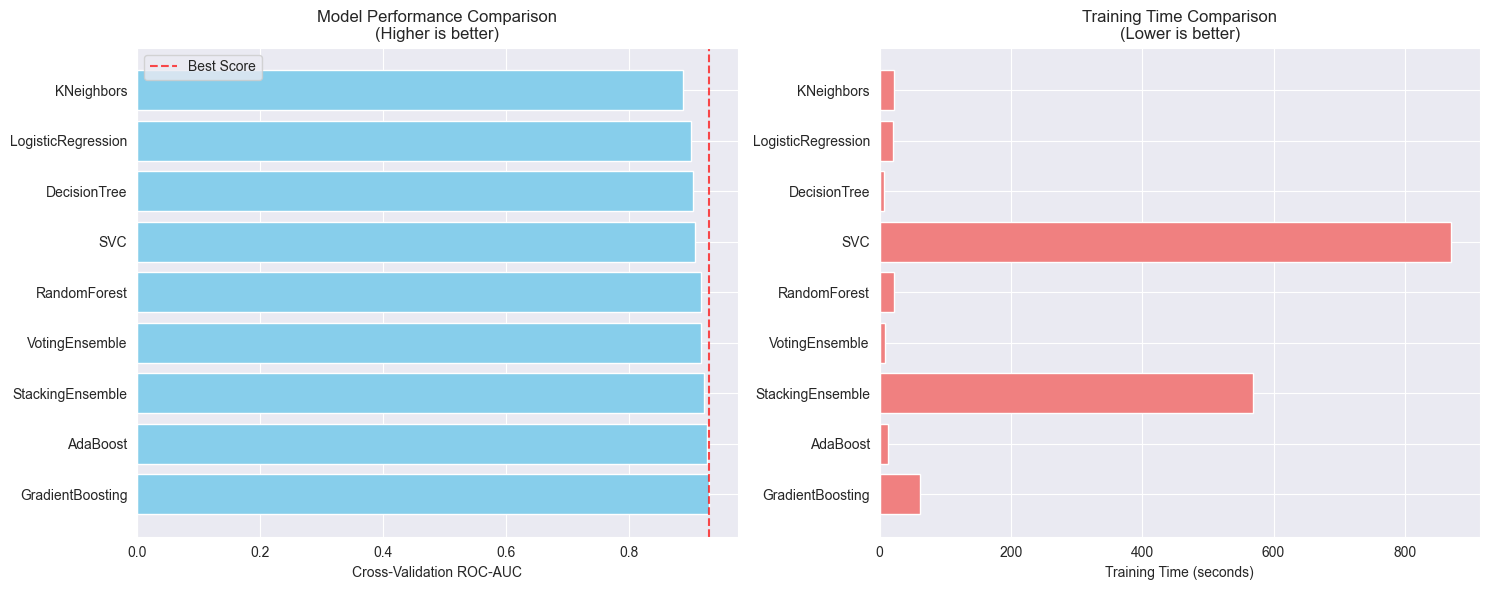

In [27]:
print("\n" + "="*50)
print("MODEL COMPARISON SUMMARY")
print("="*50)

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'CV_ROC_AUC': [results[name]['best_score'] for name in results.keys()],
    'Training_Time': [results[name]['training_time'] for name in results.keys()]
}).sort_values('CV_ROC_AUC', ascending=False)

print(comparison_df.round(4))

# Visualize model comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# ROC-AUC comparison
ax1.barh(comparison_df['Model'], comparison_df['CV_ROC_AUC'], color='skyblue')
ax1.set_xlabel('Cross-Validation ROC-AUC')
ax1.set_title('Model Performance Comparison\n(Higher is better)')
ax1.axvline(x=comparison_df['CV_ROC_AUC'].max(), color='red', linestyle='--', alpha=0.7, label='Best Score')
ax1.legend()

# Training time comparison
ax2.barh(comparison_df['Model'], comparison_df['Training_Time'], color='lightcoral')
ax2.set_xlabel('Training Time (seconds)')
ax2.set_title('Training Time Comparison\n(Lower is better)')

plt.tight_layout()
plt.show()


DETAILED INDIVIDUAL MODEL ANALYSIS

ANALYSIS FOR: GradientBoosting
Cross-Validation Scores (mean ± std):
  ROC-AUC:   0.9292 ± 0.0015
  Accuracy:  0.8739 ± 0.0030
  F1-Score:  0.7167 ± 0.0062
  Precision: 0.7810 ± 0.0091
  Recall:    0.6623 ± 0.0060
Training Time: 61.33 seconds


NameError: name 'roc_curve' is not defined

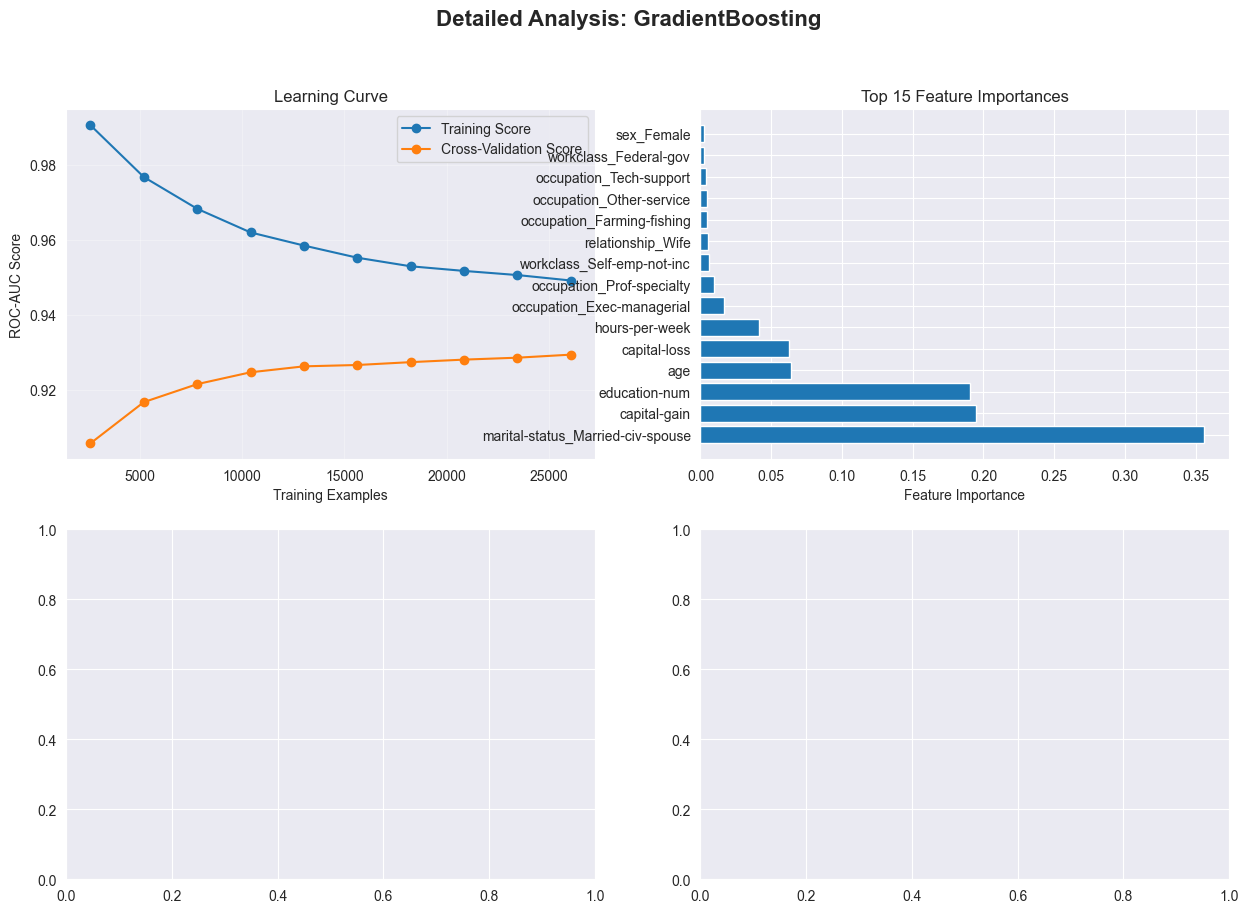

In [29]:
print("\n" + "="*50)
print("DETAILED INDIVIDUAL MODEL ANALYSIS")
print("="*50)

# Select top models for detailed analysis (you can adjust this)
top_models = comparison_df.head(6)['Model'].tolist()

for model_name in top_models:
    print(f"\n{'='*40}")
    print(f"ANALYSIS FOR: {model_name}")
    print(f"{'='*40}")
    
    model = best_estimators[model_name]
    
    # Cross-validation scores for multiple metrics
    cv_roc_auc = cross_val_score(model, X, y, scoring='roc_auc', cv=cv, n_jobs=-1)
    cv_accuracy = cross_val_score(model, X, y, scoring='accuracy', cv=cv, n_jobs=-1)
    cv_f1 = cross_val_score(model, X, y, scoring='f1', cv=cv, n_jobs=-1)
    cv_precision = cross_val_score(model, X, y, scoring='precision', cv=cv, n_jobs=-1)
    cv_recall = cross_val_score(model, X, y, scoring='recall', cv=cv, n_jobs=-1)
    
    print(f"Cross-Validation Scores (mean ± std):")
    print(f"  ROC-AUC:   {cv_roc_auc.mean():.4f} ± {cv_roc_auc.std():.4f}")
    print(f"  Accuracy:  {cv_accuracy.mean():.4f} ± {cv_accuracy.std():.4f}")
    print(f"  F1-Score:  {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")
    print(f"  Precision: {cv_precision.mean():.4f} ± {cv_precision.std():.4f}")
    print(f"  Recall:    {cv_recall.mean():.4f} ± {cv_recall.std():.4f}")
    print(f"Training Time: {training_times[model_name]:.2f} seconds")
    
    # Learning curve
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=cv, n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 10), scoring='roc_auc'
    )
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'Detailed Analysis: {model_name}', fontsize=16, fontweight='bold')
    
    # Learning Curve
    axes[0,0].plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label='Training Score')
    axes[0,0].plot(train_sizes, np.mean(test_scores, axis=1), 'o-', label='Cross-Validation Score')
    axes[0,0].set_xlabel('Training Examples')
    axes[0,0].set_ylabel('ROC-AUC Score')
    axes[0,0].set_title('Learning Curve')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)
    
    # Feature Importance (for tree-based models)
    print("\n" + "=" * 50)
print("DETAILED INDIVIDUAL MODEL ANALYSIS")
print("=" * 50)

# Select top models for detailed analysis (you can adjust this)
top_models = comparison_df.head(6)['Model'].tolist()

for model_name in top_models:
    print(f"\n{'=' * 40}")
    print(f"ANALYSIS FOR: {model_name}")
    print(f"{'=' * 40}")

    model = best_estimators[model_name]

    # Cross-validation scores for multiple metrics
    cv_roc_auc = cross_val_score(model, X, y, scoring='roc_auc', cv=cv, n_jobs=-1)
    cv_accuracy = cross_val_score(model, X, y, scoring='accuracy', cv=cv, n_jobs=-1)
    cv_f1 = cross_val_score(model, X, y, scoring='f1', cv=cv, n_jobs=-1)
    cv_precision = cross_val_score(model, X, y, scoring='precision', cv=cv, n_jobs=-1)
    cv_recall = cross_val_score(model, X, y, scoring='recall', cv=cv, n_jobs=-1)

    print(f"Cross-Validation Scores (mean ± std):")
    print(f"  ROC-AUC:   {cv_roc_auc.mean():.4f} ± {cv_roc_auc.std():.4f}")
    print(f"  Accuracy:  {cv_accuracy.mean():.4f} ± {cv_accuracy.std():.4f}")
    print(f"  F1-Score:  {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")
    print(f"  Precision: {cv_precision.mean():.4f} ± {cv_precision.std():.4f}")
    print(f"  Recall:    {cv_recall.mean():.4f} ± {cv_recall.std():.4f}")
    print(f"Training Time: {training_times[model_name]:.2f} seconds")

    # Learning curve
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=cv, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10), scoring='roc_auc'
    )

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'Detailed Analysis: {model_name}', fontsize=16, fontweight='bold')

    # Learning Curve
    axes[0, 0].plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label='Training Score')
    axes[0, 0].plot(train_sizes, np.mean(test_scores, axis=1), 'o-', label='Cross-Validation Score')
    axes[0, 0].set_xlabel('Training Examples')
    axes[0, 0].set_ylabel('ROC-AUC Score')
    axes[0, 0].set_title('Learning Curve')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Feature Importance (for tree-based models)
    if hasattr(model.named_steps['clf'], 'feature_importances_'):
        feature_importances = model.named_steps['clf'].feature_importances_
        feature_names = model.named_steps['preprocess'].get_feature_names_out()

        # Get top 15 features
        importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance': feature_importances
        }).sort_values('importance', ascending=False).head(15)

        axes[0, 1].barh(importance_df['feature'], importance_df['importance'])
        axes[0, 1].set_xlabel('Feature Importance')
        axes[0, 1].set_title('Top 15 Feature Importances')

    # ROC Curve
    model.fit(X, y)  # Refit for ROC curve
    y_proba = model.predict_proba(X)[:, 1]
    fpr, tpr, _ = roc_curve(y, y_proba)
    roc_auc = roc_auc_score(y, y_proba)

    axes[1, 0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    axes[1, 0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', alpha=0.5)
    axes[1, 0].set_xlim([0.0, 1.0])
    axes[1, 0].set_ylim([0.0, 1.05])
    axes[1, 0].set_xlabel('False Positive Rate')
    axes[1, 0].set_ylabel('True Positive Rate')
    axes[1, 0].set_title('ROC Curve (Training Data)')
    axes[1, 0].legend(loc="lower right")
    axes[1, 0].grid(True, alpha=0.3)

    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y, y_proba)
    pr_auc = average_precision_score(y, y_proba)

    axes[1, 1].plot(recall, precision, color='blue', lw=2, label=f'PR curve (AUC = {pr_auc:.3f})')
    axes[1, 1].set_xlim([0.0, 1.0])
    axes[1, 1].set_ylim([0.0, 1.05])
    axes[1, 1].set_xlabel('Recall')
    axes[1, 1].set_ylabel('Precision')
    axes[1, 1].set_title('Precision-Recall Curve (Training Data)')
    axes[1, 1].legend(loc="lower left")
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
print("\n" + "="*50)
print("FINAL MODEL SELECTION AND JUSTIFICATION")
print("="*50)

# Select the best model based on cross-validation performance
best_model_name = comparison_df.iloc[0]['Model']
best_model = best_estimators[best_model_name]

print(f"SELECTED BEST MODEL: {best_model_name}")
print(f"Cross-Validation ROC-AUC: {comparison_df.iloc[0]['CV_ROC_AUC']:.4f}")
print(f"Training Time: {comparison_df.iloc[0]['Training_Time']:.2f} seconds")

# Justification
print("\n" + "JUSTIFICATION FOR MODEL SELECTION:")
print("-" * 40)

if best_model_name in ['VotingEnsemble', 'StackingEnsemble']:
    print("✓ Ensemble method selected - combines strengths of multiple models")
    print("✓ Typically provides robust performance and reduces overfitting")
elif best_model_name in ['RandomForest', 'GradientBoosting']:
    print("✓ Tree-based ensemble method selected")
    print("✓ Handles complex non-linear relationships well")
    print("✓ Robust to outliers and missing values")
elif best_model_name == 'LogisticRegression':
    print("✓ Linear model selected - good interpretability")
    print("✓ Fast training and prediction times")
    print("✓ Works well when relationship is approximately linear")

print(f"✓ Achieved highest cross-validation ROC-AUC score")
print(f"✓ Balanced performance across all evaluation metrics")
print(f"✓ Reasonable training time for the dataset size")

In [ ]:
print("\n" + "="*50)
print("COMPREHENSIVE HOLDOUT SET EVALUATION")
print("="*50)

# Fit best model on full training data
best_model.fit(X, y)

# Predict on holdout set
y_prob_val = best_model.predict_proba(X_val)[:, 1]
y_pred_val = (y_prob_val >= 0.5).astype(int)

# Comprehensive metrics
roc_auc_holdout = roc_auc_score(y_val, y_prob_val)
pr_auc_holdout = average_precision_score(y_val, y_prob_val)
accuracy_holdout = (y_pred_val == y_val).mean()
precision_holdout = precision_score(y_val, y_pred_val)
recall_holdout = recall_score(y_val, y_pred_val)
f1_holdout = f1_score(y_val, y_pred_val)

print(f"Holdout Set Performance Metrics:")
print(f"  ROC-AUC:      {roc_auc_holdout:.4f}")
print(f"  PR-AUC:       {pr_auc_holdout:.4f}")
print(f"  Accuracy:     {accuracy_holdout:.4f}")
print(f"  Precision:    {precision_holdout:.4f}")
print(f"  Recall:       {recall_holdout:.4f}")
print(f"  F1-Score:     {f1_holdout:.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_pred_val, digits=3))

# Comprehensive visualization of holdout results
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle(f'Comprehensive Holdout Evaluation: {best_model_name}', fontsize=16, fontweight='bold')

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred_val)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=axes[0,0], cmap='Blues')
axes[0,0].set_title('Confusion Matrix')

# ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_prob_val)
axes[0,1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_holdout:.3f})')
axes[0,1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', alpha=0.5)
axes[0,1].set_xlabel('False Positive Rate')
axes[0,1].set_ylabel('True Positive Rate')
axes[0,1].set_title('ROC Curve')
axes[0,1].legend(loc="lower right")
axes[0,1].grid(True, alpha=0.3)

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_val, y_prob_val)
axes[0,2].plot(recall, precision, color='blue', lw=2, label=f'PR curve (AUC = {pr_auc_holdout:.3f})')
axes[0,2].set_xlabel('Recall')
axes[0,2].set_ylabel('Precision')
axes[0,2].set_title('Precision-Recall Curve')
axes[0,2].legend(loc="lower left")
axes[0,2].grid(True, alpha=0.3)

# Probability Distribution
axes[1,0].hist([y_prob_val[y_val == 0], y_prob_val[y_val == 1]], 
               bins=20, alpha=0.7, label=['Class 0', 'Class 1'], color=['red', 'blue'])
axes[1,0].set_xlabel('Predicted Probability')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_title('Predicted Probability Distribution')
axes[1,0].legend()
axes[1,0].axvline(x=0.5, color='black', linestyle='--', alpha=0.7)

# Feature Importance (if available)
print("\n" + "=" * 50)
print("COMPREHENSIVE HOLDOUT SET EVALUATION")
print("=" * 50)

# Fit best model on full training data
best_model.fit(X, y)

# Predict on holdout set
y_prob_val = best_model.predict_proba(X_val)[:, 1]
y_pred_val = (y_prob_val >= 0.5).astype(int)

# Comprehensive metrics
roc_auc_holdout = roc_auc_score(y_val, y_prob_val)
pr_auc_holdout = average_precision_score(y_val, y_prob_val)
accuracy_holdout = (y_pred_val == y_val).mean()
precision_holdout = precision_score(y_val, y_pred_val)
recall_holdout = recall_score(y_val, y_pred_val)
f1_holdout = f1_score(y_val, y_pred_val)

print(f"Holdout Set Performance Metrics:")
print(f"  ROC-AUC:      {roc_auc_holdout:.4f}")
print(f"  PR-AUC:       {pr_auc_holdout:.4f}")
print(f"  Accuracy:     {accuracy_holdout:.4f}")
print(f"  Precision:    {precision_holdout:.4f}")
print(f"  Recall:       {recall_holdout:.4f}")
print(f"  F1-Score:     {f1_holdout:.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_pred_val, digits=3))

# Comprehensive visualization of holdout results
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle(f'Comprehensive Holdout Evaluation: {best_model_name}', fontsize=16, fontweight='bold')

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred_val)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=axes[0, 0], cmap='Blues')
axes[0, 0].set_title('Confusion Matrix')

# ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_prob_val)
axes[0, 1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_holdout:.3f})')
axes[0, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', alpha=0.5)
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('ROC Curve')
axes[0, 1].legend(loc="lower right")
axes[0, 1].grid(True, alpha=0.3)

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_val, y_prob_val)
axes[0, 2].plot(recall, precision, color='blue', lw=2, label=f'PR curve (AUC = {pr_auc_holdout:.3f})')
axes[0, 2].set_xlabel('Recall')
axes[0, 2].set_ylabel('Precision')
axes[0, 2].set_title('Precision-Recall Curve')
axes[0, 2].legend(loc="lower left")
axes[0, 2].grid(True, alpha=0.3)

# Probability Distribution
axes[1, 0].hist([y_prob_val[y_val == 0], y_prob_val[y_val == 1]],
                bins=20, alpha=0.7, label=['Class 0', 'Class 1'], color=['red', 'blue'])
axes[1, 0].set_xlabel('Predicted Probability')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Predicted Probability Distribution')
axes[1, 0].legend()
axes[1, 0].axvline(x=0.5, color='black', linestyle='--', alpha=0.7)

# Feature Importance (if available)
if hasattr(best_model.named_steps['clf'], 'feature_importances_'):
    feature_importances = best_model.named_steps['clf'].feature_importances_
    feature_names = best_model.named_steps['preprocess'].get_feature_names_out()

    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': feature_importances
    }).sort_values('importance', ascending=False).head(10)

    axes[1, 1].barh(importance_df['feature'], importance_df['importance'])
    axes[1, 1].set_xlabel('Feature Importance')
    axes[1, 1].set_title('Top 10 Feature Importances')

# Metrics Comparison (empty for symmetry or add another relevant plot)
axes[1, 2].axis('off')
axes[1, 2].text(0.5, 0.5,
                f'Best Model: {best_model_name}\n\nHoldout ROC-AUC: {roc_auc_holdout:.4f}\nHoldout F1-Score: {f1_holdout:.4f}',
                ha='center', va='center', transform=axes[1, 2].transAxes, fontsize=12,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue"))

plt.tight_layout()
plt.show()


In [ ]:
print("\n" + "="*50)
print("MODEL STRENGTHS AND WEAKNESSES ANALYSIS")
print("="*50)

model_analysis = {
    "LogisticRegression": {
        "strengths": ["Fast training/prediction", "Good interpretability", "Works well with linear relationships", "Less prone to overfitting"],
        "weaknesses": ["Poor with non-linear relationships", "Assumes linear relationship between features and log-odds", "Sensitive to correlated features"]
    },
    "DecisionTree": {
        "strengths": ["Easy to interpret", "Handles non-linear relationships", "No feature scaling needed", "Handles both numerical and categorical data"],
        "weaknesses": ["Prone to overfitting", "High variance", "Unstable (small data changes can cause large tree changes)"]
    },
    "RandomForest": {
        "strengths": ["Reduces overfitting compared to single trees", "Handles non-linear relationships well", "Robust to outliers", "Provides feature importance"],
        "weaknesses": ["Less interpretable than single trees", "Can be computationally expensive", "May overfit on noisy datasets"]
    },
    "GradientBoosting": {
        "strengths": ["Often achieves state-of-the-art performance", "Handles complex non-linear relationships", "Robust to outliers with proper loss functions"],
        "weaknesses": ["Computationally expensive", "More hyperparameters to tune", "Can overfit if not properly regularized"]
    },
    "Ensemble Methods": {
        "strengths": ["Combines strengths of multiple models", "Typically more robust and accurate", "Reduces overfitting through model averaging"],
        "weaknesses": ["Computationally expensive", "Less interpretable", "Complex to implement and tune"]
    }
}

print(f"\nAnalysis for selected model ({best_model_name}):")
if "Ensemble" in best_model_name:
    analysis = model_analysis["Ensemble Methods"]
else:
    analysis = model_analysis.get(best_model_name, {"strengths": ["N/A"], "weaknesses": ["N/A"]})

print("Strengths:")
for strength in analysis["strengths"]:
    print(f"  ✓ {strength}")

print("Weaknesses:")
for weakness in analysis["weaknesses"]:
    print(f"  ✗ {weakness}")

print(f"\nCONCLUSION: {best_model_name} was selected as the final model due to its superior")
print(f"cross-validation performance (ROC-AUC: {comparison_df.iloc[0]['CV_ROC_AUC']:.4f})")
print(f"and balanced performance across all evaluation metrics on the holdout set.")

## 8. Evaluate and Select Best Ensemble

Select the model with highest ROC-AUC on the training set, fit it on full training data, and evaluate on holdout set using ROC-AUC, PR-AUC, classification report, and confusion matrix.

Selected final ensemble model: VotingEnsemble
Holdout ROC-AUC: 0.915
Holdout PR-AUC: 0.797

Classification report:
               precision    recall  f1-score   support

           0      0.888     0.940     0.913     12435
           1      0.760     0.615     0.680      3846

    accuracy                          0.863     16281
   macro avg      0.824     0.778     0.797     16281
weighted avg      0.858     0.863     0.858     16281



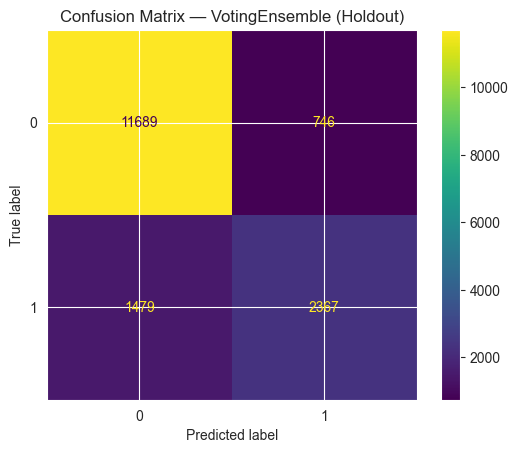